In [1]:
from helper_PP_GP import prepare_data_from_parquet, train_model, compute_meta, plot_pp_overview, evaluate_test_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
parquet_path = "../data/processed/cpr_gfw_2024.parquet"   # change to your path
train_coords, train_covs, train_y, test_coords, test_covs, test_y, scalers, df = prepare_data_from_parquet(parquet_path)
meta = compute_meta(df)

print("N:", train_coords.shape[0], "M features:", train_coords.shape[1])

# train
model, losses = train_model(train_coords, train_covs, train_y,
                            M=300,       # inducing points
                            lr=1e-2,
                            num_steps=1000,
                            minibatch=1024,
                            device="cpu")  # or "cuda" if available



N: 24346 M features: 3


/home/romina/miniconda3/envs/py314/lib/python3.14/site-packages/torch/autograd/graph.py:841: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


16509.259765625
16210.994140625
15618.126953125
12909.703125
13452.78515625
11815.5546875
10710.5009765625
11754.046875
10757.0205078125
10457.478515625
9838.583984375
10403.255859375
9840.6416015625
11674.4384765625
10880.70703125
9030.6396484375
11156.8896484375
10041.1904296875
9579.0009765625
10336.8642578125
10751.333984375


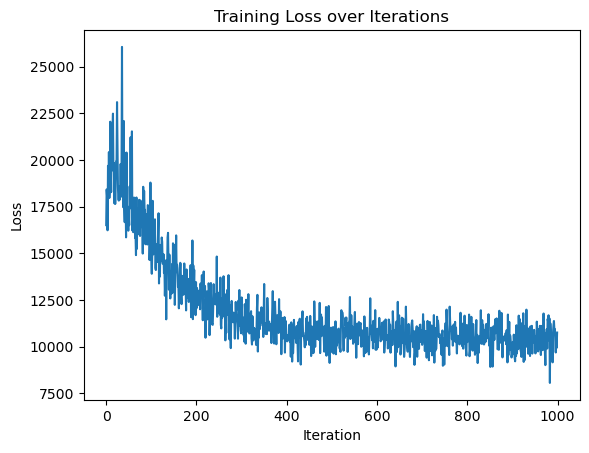

In [3]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.show()

In [4]:
# Merge train and test
all_coords = np.vstack([train_coords, test_coords])
all_covs = np.vstack([train_covs, test_covs])
all_y = np.concatenate([train_y, test_y])

# Sort by time (3rd column)
sort_idx = np.argsort(all_coords[:, 2])
all_coords_sorted = all_coords[sort_idx]
all_covs_sorted = all_covs[sort_idx]
all_y_sorted = all_y[sort_idx]
rate_mean, rate_p05, rate_p95 = model.predict_rate(all_coords_sorted, all_covs_sorted, num_samples=200)


In [5]:
# Convert test_coords[:,2] (normalized time) back to datetime
t_norm_test = test_coords[:, 2]
test_dates = pd.to_datetime(meta["t_min"]) + pd.to_timedelta(
    t_norm_test * (meta["t_max"] - meta["t_min"])
)

# Pick a random date from test_dates
rng = np.random.default_rng(seed=42)
target_np = rng.choice(test_dates)  # numpy.datetime64
target_date = pd.to_datetime(target_np).date() # convert to datetime.date

print("Randomly chosen test date:", target_date)

Randomly chosen test date: 2022-06-04


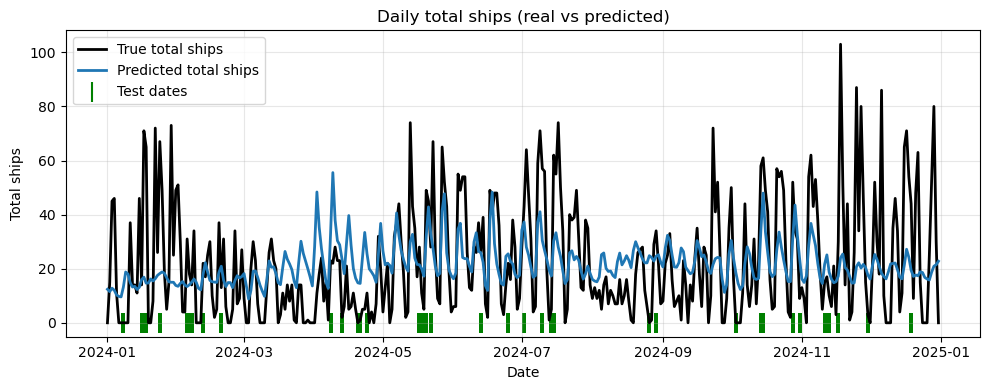

Selected closest available date: 2022-06-04 (normalized -1.576)


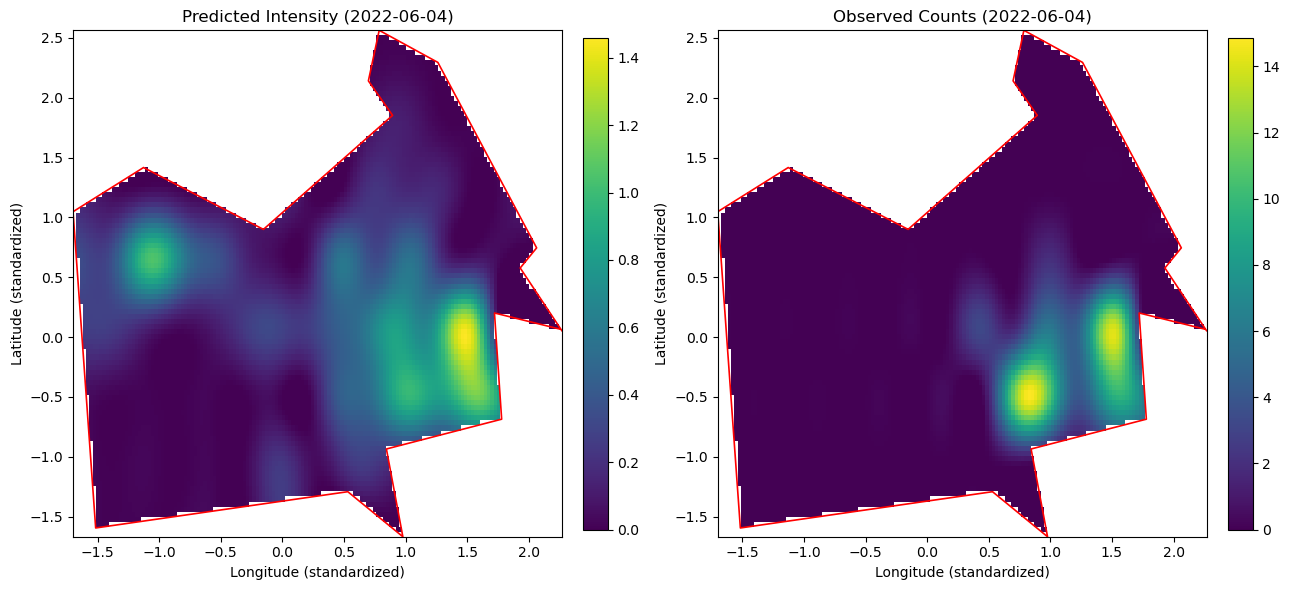

In [6]:
# Example usage
plot_pp_overview(
    model, 
    df,
    all_coords_sorted, 
    all_covs_sorted, 
    y_true=all_y_sorted, 
    meta=meta, 
    num_samples=200, 
    target_date=target_date,
    test_coords = test_coords,
    t_scaler = scalers["t_scaler"]
)


In [7]:
rate_mean_test, rate_p05_test, rate_p95_test = model.predict_rate(test_coords, test_covs, num_samples=200)

metrics = evaluate_test_metrics(test_y, rate_mean_test,test_dates)
print("Mean log-likelihood (per obs):", metrics["mean_ll_obs"])
print("Daily RMSE:", metrics["rmse_daily"])
print("Daily mean log-likelihood:", metrics["mean_ll_daily"])

Mean log-likelihood (per obs): -0.5806943593076512
Daily RMSE: 16.97537037245446
Daily mean log-likelihood: -9.24403869707871
